# Customer Segmentation Using K-Means Clustering

Full pipeline: data loading, cleaning, feature engineering, EDA, K-Means clustering, and model export for Streamlit app.

**In VS Code:** Select the kernel (e.g. Python 3), then use **Run All** (or run cells in order from top to bottom) so that every variable is defined before it is used.

## 1. Imports and load data

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [37]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [38]:
df.shape

(2240, 29)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## 2. Missing values

In [40]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [41]:
df.dropna(inplace=True)
df.isna().sum().sum()

0

In [42]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 2b. Categorical columns - unique value counts

In [43]:
# Unique values for categorical columns
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [44]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

## 3. Feature engineering

In [45]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [46]:
df['Age'] = 2025 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [47]:
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_columns].sum(axis=1)

In [48]:
df['Customer_Since_Days'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days
df[['Age', 'Total_Children', 'Total_Spending', 'Customer_Since_Days']].head()

,Age,Total_Children,Total_Spending,Customer_Since_Days
0,68,0,1617,4934
1,71,2,27,4384
2,60,0,776,4583
3,41,1,53,4410
4,44,1,422,4432


## 4. Exploratory data analysis

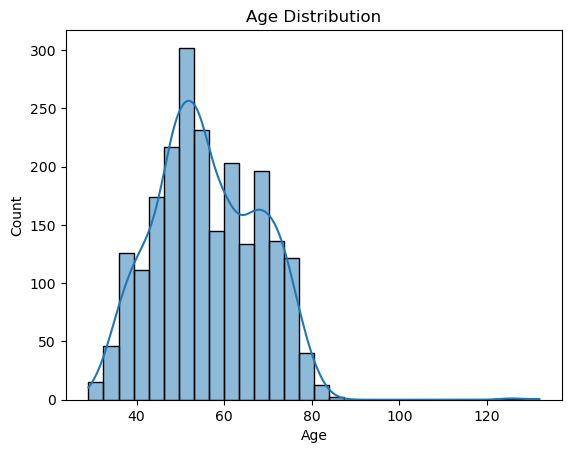

In [49]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

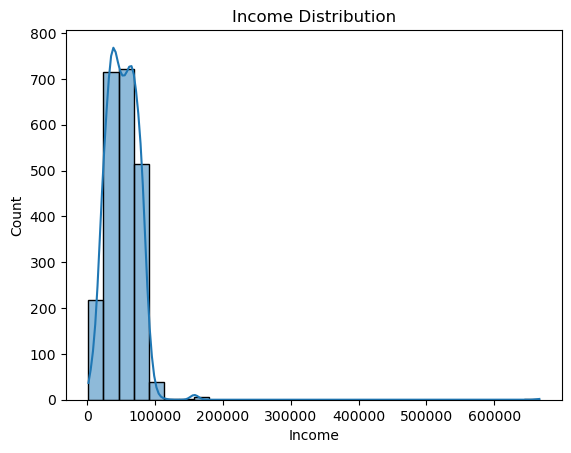

In [50]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title('Income Distribution')
plt.show()

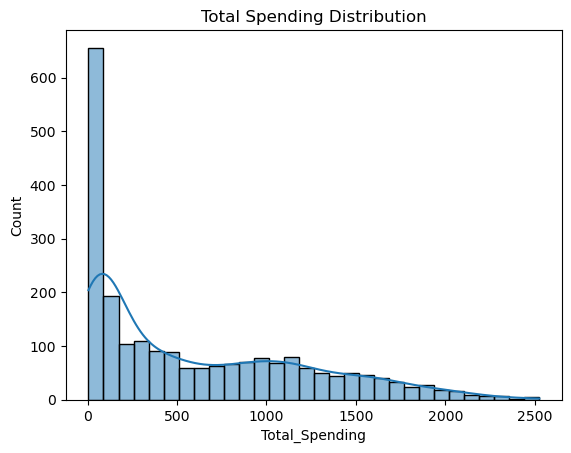

In [51]:
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title('Total Spending Distribution')
plt.show()

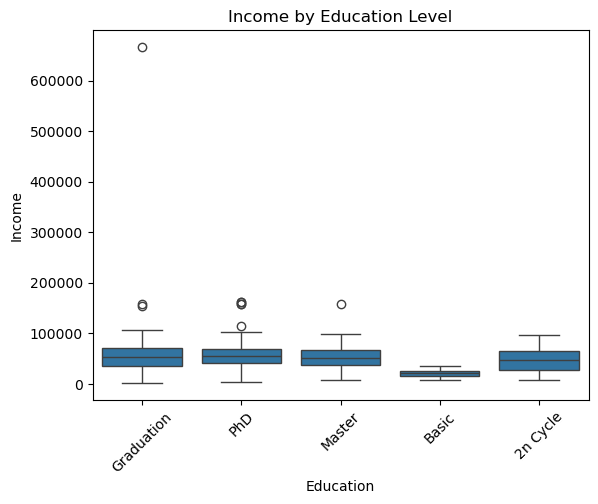

In [52]:
sns.boxplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)
plt.title('Income by Education Level')
plt.show()

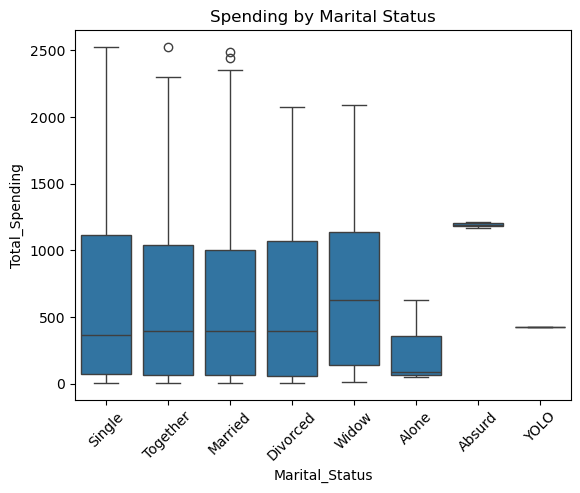

In [53]:
sns.boxplot(x='Marital_Status', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title('Spending by Marital Status')
plt.show()

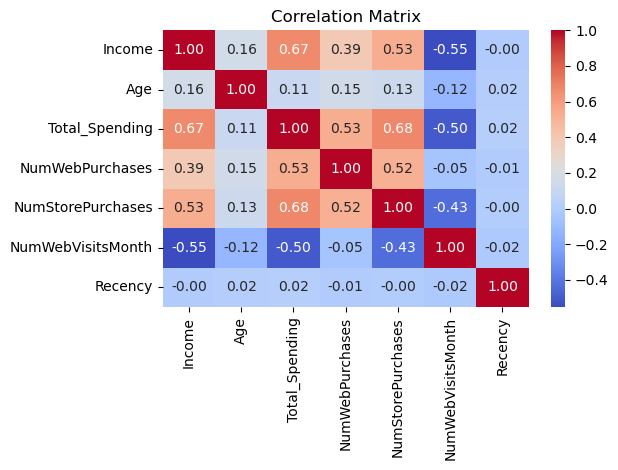

In [54]:
correlation_cols = ['Income', 'Age', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
correlation = df[correlation_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

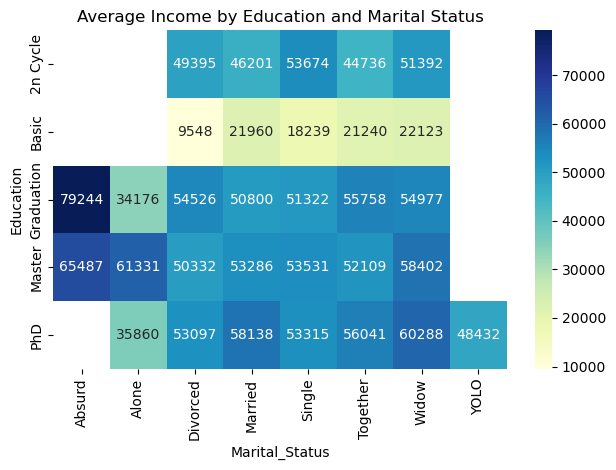

In [55]:
pivot_income = df.pivot_table(values='Income', index='Education', columns='Marital_Status', aggfunc='mean')
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Income by Education and Marital Status')
plt.tight_layout()
plt.show()

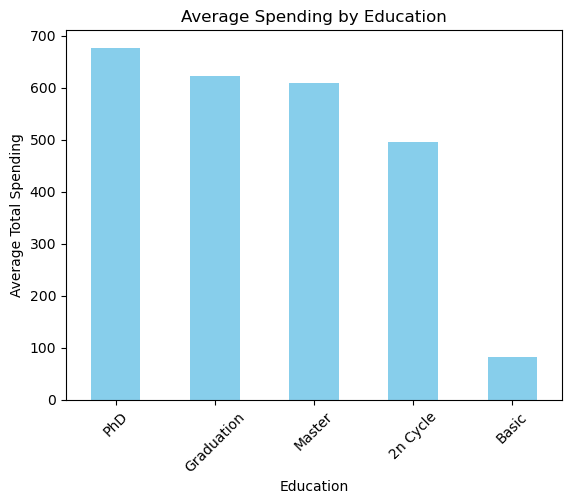

In [56]:
group1 = df.groupby('Education', observed=True)['Total_Spending'].mean().sort_values(ascending=False)
group1.plot(kind='bar', color='skyblue')
plt.title('Average Spending by Education')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=45)
plt.show()

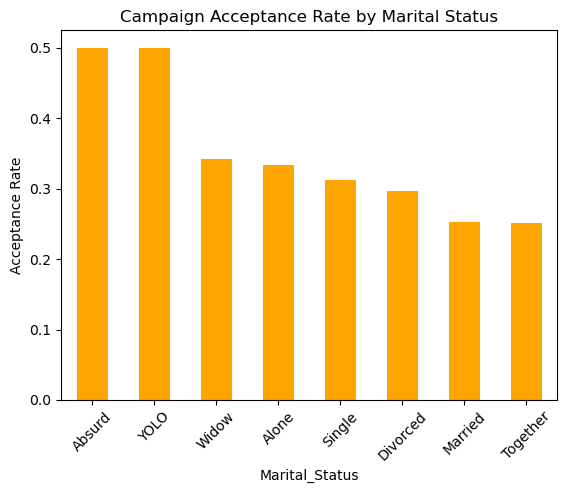

In [57]:
df['Accepted_Any'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']).apply(lambda x: 1 if x > 0 else 0)
group2 = df.groupby('Marital_Status', observed=True)['Accepted_Any'].mean().sort_values(ascending=False)
group2.plot(kind='bar', color='orange')
plt.title('Campaign Acceptance Rate by Marital Status')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.show()

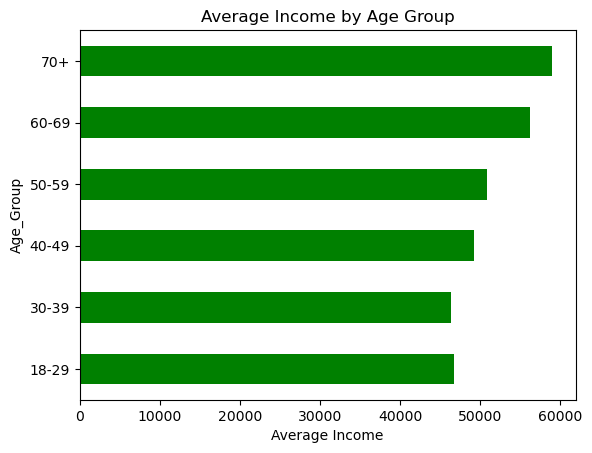

In [58]:
bins = [0, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
group3 = df.groupby('Age_Group', observed=True)['Income'].mean()
group3.plot(kind='barh', color='green')
plt.title('Average Income by Age Group')
plt.xlabel('Average Income')
plt.show()

## 5. Clustering with K-Means

In [59]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
X = df[features].copy()

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
from sklearn.cluster import KMeans
inertias = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

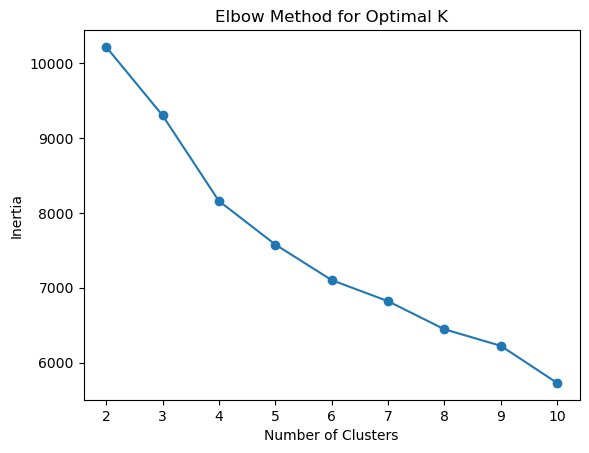

In [62]:
plt.plot(range(2, 11), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [63]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df[['Cluster'] + features].head(10)

,Cluster,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,3,68,58138.0,1617,8,4,7,58
1,5,71,46344.0,27,1,2,5,38
2,3,60,71613.0,776,8,10,4,26
3,0,41,26646.0,53,2,4,6,26
4,2,44,58293.0,422,5,6,5,94
5,3,58,62513.0,716,6,10,6,16
6,3,54,55635.0,590,7,7,6,34
7,0,40,33454.0,169,4,4,8,32
8,0,51,30351.0,46,3,2,9,19
9,2,75,5648.0,49,1,0,20,68


### 5b. Cluster summary

Average value of each feature per cluster (so you can describe each segment). Run the cells above first so `df`, `features`, and `Cluster` exist.

In [64]:
# Requires: df, features, and 'Cluster' from cells above. Run cells in order (e.g. Run All).
cluster_summary = df.groupby('Cluster', observed=True)[features].mean()
print('Mean of each feature by cluster:')
display(round(cluster_summary, 2))
print('\nNumber of customers per cluster:')
display(df['Cluster'].value_counts().sort_index())

Mean of each feature by cluster:


,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,48.76,32837.70,114.06,2.16,3.24,6.65,24.43
1,46.09,75444.85,1307.27,4.76,8.80,2.79,48.69
2,49.09,32783.94,116.76,2.34,3.20,7.07,77.01
3,59.73,59554.17,884.24,7.86,7.93,6.40,46.10
4,68.98,77107.88,1205.72,4.54,8.23,2.53,52.89
5,68.03,43426.75,170.50,2.58,4.02,5.37,52.10



Number of customers per cluster:


Cluster
0    452
1    334
2    367
3    430
4    315
5    318
Name: count, dtype: int64

In [65]:
df['Cluster'].value_counts().sort_index()

Cluster
0    452
1    334
2    367
3    430
4    315
5    318
Name: count, dtype: int64

## 6. Visualize clusters with PCA

In [66]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

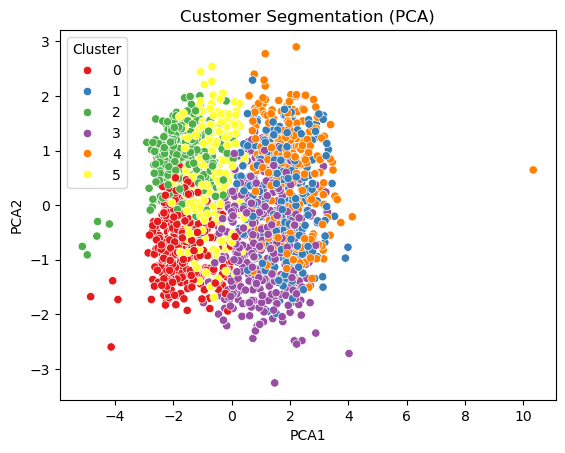

In [67]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segmentation (PCA)')
plt.show()

## 7. Export model and scaler for Streamlit app

In [68]:
import joblib
from pathlib import Path

# Save to the same folder as customer_segmentation.csv (project folder)
project_dir = Path('customer_segmentation.csv').resolve().parent
joblib.dump(kmeans, project_dir / 'kmeans_model.pickle')
joblib.dump(scaler, project_dir / 'scaler.pickle')
print('Model and scaler saved to:', project_dir)
print('Run: streamlit run segmentation.py')

Model and scaler saved. Run: streamlit run segmentation.py
